# Statistical Measures for ML

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute basic statistical properties of datasets
- Use mean, variance, covariance, correlation
- Apply measures in ML preprocessing and analysis

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process Using Python and Pandas" — you read the Titanic table's spread and skew off `describe()`; here we define the quantities that summary prints.

**Used later in:** Course 05 (AIAT 115) — Unit 2, lesson 03 "Outliers & Data Transformation" — Z-score and IQR outlier rules are built directly from these.

---


---

## 📌 Real case: four datasets, one set of statistics

In 1973 the statistician Frank Anscombe published four small datasets in *The American Statistician*.
They share, to the precision you would normally report: mean of x = 9, variance of x = 11, mean of
y = 7.50, variance of y = 4.125, correlation = 0.816, the same regression line **y = 3.00 + 0.500x**, and
the same R² = 0.67. Plot them and one is a clean linear relationship, one is a perfect curve, one is a
straight line dragged off course by a single outlier, and one is a vertical stack of points with a single
distant point setting the entire slope. **Anscombe's quartet** exists to make one point: almost every
summary statistic in this notebook — the fitted line, R², MSE and RMSE — can be identical for datasets you
would treat completely differently. (MAE is the one that does differ across the four: 0.72 to 0.97.)

Forty-four years later Justin Matejka and George Fitzmaurice pushed it further at CHI 2017 with the
**"Datasaurus Dozen"** — thirteen datasets sharing summary statistics to two decimal places, one of which
is a picture of a dinosaur.

**What goes wrong without this.** The metrics below (MSE 2900.19, MAE 42.79, RMSE 53.85, R² 0.4526) are
what you will put in a report about a model that predicts real patients' disease progression. Anscombe's
point is that those four numbers do not determine the picture. Compute them *and* plot the residuals —
which is exactly what the visualization cell below does, and why it is there.


# Statistical Measures for ML

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 2: Loss Functions** - Understand how to measure error
- ✅ **Basic statistics**: Mean, variance, standard deviation

**If you haven't completed these**, you might struggle with:
- Understanding evaluation metrics
- Understanding R² score

---

## 🔗 Where This Notebook Fits

**This is the THIRD example of Module 03** - how to evaluate models!

**Why this example THIRD?**
- **Before** you can evaluate models, you need loss functions (Example 2)
- **Before** you can compare models, you need metrics

**Builds on**: Example 2 (loss functions)

**Leads to**: Module 05: Statistical Inference

---

## The Story: Understanding Before Using

Imagine you're judging a competition. **Before** you can judge, you need criteria. **After** understanding statistical measures, you have objective ways to evaluate models!

Same with machine learning: **Before** deploying models, we need to know they work. **After** understanding statistical measures, we can objectively evaluate model performance!

---

## Why This Concept Matters

### Why Statistical Measures Matter in ML

**WHY** are statistical measures essential?

1. **Objective Evaluation**:
   - **WHY**: Need numbers to compare models
   - **HOW**: Compute error metrics
   - **AFTER**: Can objectively compare models

2. **Model Selection**:
   - **WHY**: Need to choose best model
   - **HOW**: Compare metrics
   - **AFTER**: Deploy best model

## Learning Objectives
1. Understand evaluation metrics (MSE, MAE, R²)
2. Compute statistical measures
3. Interpret results
4. Compare model performance

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib for the maths and plots, plus sklearn to train a REAL model
# whose real errors we will measure.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

print('✅ Libraries imported successfully!')


✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

Example 1: Statistical Measures
WHY: Need objective way to evaluate models
HOW: Compute error metrics


In [2]:
# Example 1: Statistical Measures on a REAL model's REAL errors
# WHY: Need an objective way to evaluate models
# HOW: Train a model on real data, then compute error metrics on data it never saw

# Real dataset: sklearn's diabetes study - 442 patients, 10 baseline measurements,
# target = a quantitative measure of disease progression one year later.
diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=42
)

# Train a plain linear model, then predict on the held-out patients.
model = LinearRegression()
model.fit(X_train, y_train)

targets = y_test                    # what actually happened to those patients
predictions = model.predict(X_test)  # what the model said would happen

print("Example 1: Statistical Measures")
print("=" * 60)
print(f"Held-out patients: {len(targets)}")
print(f"Targets     (first 10): {np.round(targets[:10], 2)}")
print(f"Predictions (first 10): {np.round(predictions[:10], 2)}")

# Basic statistics of the data
print(f"\nMean of targets:     {np.mean(targets):.4f}")
print(f"Variance of targets: {np.var(targets):.4f}")
print(f"Std of targets:      {np.std(targets):.4f}")

# Error metrics for model evaluation
errors = predictions - targets
mse = np.mean(errors**2)
mae = np.mean(np.abs(errors))
rmse = np.sqrt(mse)
r2 = 1 - np.sum(errors**2) / np.sum((targets - np.mean(targets))**2)
correlation = np.corrcoef(targets, predictions)[0, 1]

print(f"\nMSE  (Mean Squared Error):  {mse:.4f}")
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root MSE):            {rmse:.4f}")
print(f"R²   (Coefficient of Determination): {r2:.4f}")
print(f"Correlation (targets vs predictions): {correlation:.4f}")

print(f"\nRead these honestly: RMSE of {rmse:.1f} is on the target's own scale "
      f"(targets range {targets.min():.0f}-{targets.max():.0f}),")
print(f"and R² = {r2:.2f} means the model explains only about {r2:.0%} of the variation "
      "between patients.")
print("Real data rarely gives a near-perfect score - which is exactly why we measure.")

print(f"\n💡 WHY: Need objective way to evaluate models")
print(f"💡 HOW: Compute error metrics (MSE, MAE, RMSE, R²)")
print(f"💡 AFTER: Can compare models objectively")


Example 1: Statistical Measures
Held-out patients: 89
Targets     (first 10): [219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]
Predictions (first 10): [139.55 179.52 134.04 291.42 123.79  92.17 258.23 181.34  90.22 108.63]

Mean of targets:     145.7753
Variance of targets: 5298.1517
Std of targets:      72.7884

MSE  (Mean Squared Error):  2900.1936
MAE  (Mean Absolute Error): 42.7941
RMSE (Root MSE):            53.8534
R²   (Coefficient of Determination): 0.4526
Correlation (targets vs predictions): 0.6780

Read these honestly: RMSE of 53.9 is on the target's own scale (targets range 37-310),
and R² = 0.45 means the model explains only about 45% of the variation between patients.
Real data rarely gives a near-perfect score - which is exactly why we measure.

💡 WHY: Need objective way to evaluate models
💡 HOW: Compute error metrics (MSE, MAE, RMSE, R²)
💡 AFTER: Can compare models objectively


---

## 📊 Visualization

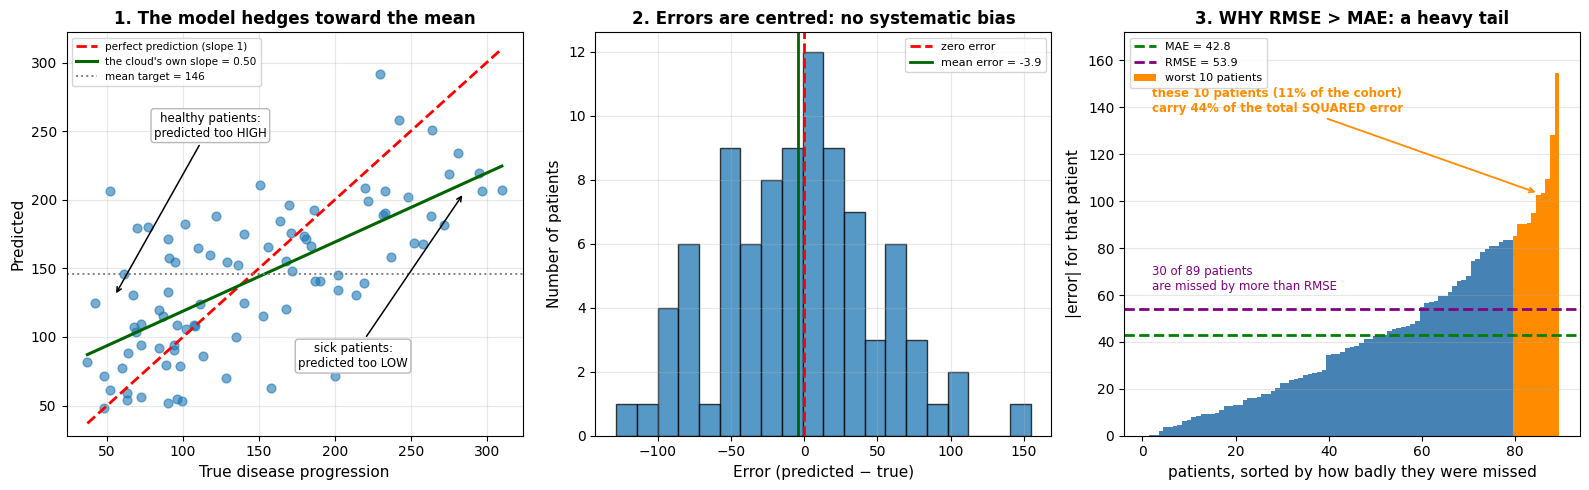


📊 Reading the three panels:
  1. Fitting a line through the prediction cloud gives slope 0.503, not 1.0.
     The model pulls every patient toward the average — good for MSE, bad for the
     patients at either extreme, who are exactly the ones a clinician cares about.
  2. Mean error = -3.91 on a target scale of 37–310: no meaningful systematic bias.
     The model is not consistently high or low — it is consistently IMPRECISE.
  3. 30 of 89 patients are missed by more than RMSE (53.9); the worst is off by 154.
     The 10 worst patients alone account for 44.3% of the total squared error.
     That concentration is what the MAE 42.8 vs RMSE 53.9 gap was telling you.


In [3]:
# Three diagnostic plots on the SAME 89 held-out patients: how close the predictions are,
# which direction they miss in, and WHO is being missed. Together they draw the two claims
# the metrics above only asserted — that the model shrinks toward the mean, and that a
# minority of patients carries most of the squared error.

errors = predictions - targets
abs_errors = np.abs(errors)
mae = np.mean(abs_errors)
rmse = np.sqrt(np.mean(errors**2))

fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.0))

# --- Panel 1: predictions vs targets, plus the cloud's OWN slope ------------------
# WHY fit a line through the cloud: a perfect model would give slope 1 (the red dashed
# diagonal). The slope you actually get says how much the model hedges toward the average
# patient — and that hedging is exactly why R² is lower than correlation-squared.
slope, intercept = np.polyfit(targets, predictions, 1)
t_line = np.array([targets.min(), targets.max()])
axes[0].scatter(targets, predictions, s=40, alpha=0.6)
axes[0].plot(t_line, t_line, 'r--', linewidth=2, label='perfect prediction (slope 1)')
axes[0].plot(t_line, slope * t_line + intercept, color='darkgreen', lw=2.2,
             label=f'the cloud\'s own slope = {slope:.2f}')
axes[0].axhline(targets.mean(), color='grey', ls=':', lw=1.4,
                label=f'mean target = {targets.mean():.0f}')
# White boxes behind both call-outs: they sit over a dense scatter, and grey-on-blue
# text is text the back row of the room cannot read.
_bb = dict(boxstyle='round,pad=0.25', fc='white', ec='0.7', alpha=0.92)
axes[0].annotate('sick patients:\npredicted too LOW', xy=(285, 205), xytext=(212, 78),
                 fontsize=8.5, ha='center', bbox=_bb,
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.1))
axes[0].annotate('healthy patients:\npredicted too HIGH', xy=(55, 130), xytext=(118, 246),
                 fontsize=8.5, ha='center', bbox=_bb,
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.1))
axes[0].set_ylim(28, 322)
axes[0].set_xlabel('True disease progression', fontsize=11)
axes[0].set_ylabel('Predicted', fontsize=11)
axes[0].set_title('1. The model hedges toward the mean', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=7.5, loc='upper left')
axes[0].grid(True, alpha=0.3)

# --- Panel 2: which direction the errors go --------------------------------------
axes[1].hist(errors, bins=20, alpha=0.75, edgecolor='black')
axes[1].axvline(0, color='r', linestyle='--', linewidth=2, label='zero error')
axes[1].axvline(errors.mean(), color='darkgreen', linestyle='-', linewidth=2,
                label=f'mean error = {errors.mean():.1f}')
axes[1].set_xlabel('Error (predicted − true)', fontsize=11)
axes[1].set_ylabel('Number of patients', fontsize=11)
axes[1].set_title('2. Errors are centred: no systematic bias', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# --- Panel 3: WHO the errors land on ---------------------------------------------
# WHAT: every patient's absolute error, sorted smallest to largest. WHY: the RMSE-vs-MAE
# gap in the metrics above is a claim about the SHAPE of this curve — if all errors were
# equal the curve would be flat and the two lines would coincide.
order = np.argsort(abs_errors)
sorted_ae = abs_errors[order]
rank = np.arange(1, len(sorted_ae) + 1)
worst_k = 10
share = (sorted_ae[-worst_k:] ** 2).sum() / (sorted_ae ** 2).sum()

axes[2].bar(rank, sorted_ae, width=1.0, color='steelblue', edgecolor='none')
axes[2].bar(rank[-worst_k:], sorted_ae[-worst_k:], width=1.0, color='darkorange',
            edgecolor='none', label=f'worst {worst_k} patients')
axes[2].axhline(mae, color='green', ls='--', lw=2, label=f'MAE = {mae:.1f}')
axes[2].axhline(rmse, color='purple', ls='--', lw=2, label=f'RMSE = {rmse:.1f}')
axes[2].annotate(f'these {worst_k} patients (11% of the cohort)\ncarry {share:.0%} '
                 f'of the total SQUARED error',
                 xy=(len(rank) - 4, sorted_ae[-4]), xytext=(2, 138), fontsize=8.5,
                 color='darkorange', fontweight='bold', ha='left',
                 arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.3))
axes[2].text(2, 62, f'{int((abs_errors > rmse).sum())} of {len(abs_errors)} patients\n'
                    f'are missed by more than RMSE', fontsize=8.5, color='purple')
axes[2].set_xlabel('patients, sorted by how badly they were missed', fontsize=11)
axes[2].set_ylabel('|error| for that patient', fontsize=11)
axes[2].set_title('3. WHY RMSE > MAE: a heavy tail', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=8, loc='upper left')
axes[2].set_ylim(0, 172)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Reading the three panels:")
print("=" * 72)
print(f"  1. Fitting a line through the prediction cloud gives slope {slope:.3f}, not 1.0.")
print("     The model pulls every patient toward the average — good for MSE, bad for the")
print("     patients at either extreme, who are exactly the ones a clinician cares about.")
print(f"  2. Mean error = {errors.mean():.2f} on a target scale of "
      f"{targets.min():.0f}–{targets.max():.0f}: no meaningful systematic bias.")
print(f"     The model is not consistently high or low — it is consistently IMPRECISE.")
print(f"  3. {int((abs_errors > rmse).sum())} of {len(abs_errors)} patients are missed by "
      f"more than RMSE ({rmse:.1f}); the worst is off by {abs_errors.max():.0f}.")
print(f"     The {worst_k} worst patients alone account for {share:.1%} of the total squared error.")
print(f"     That concentration is what the MAE {mae:.1f} vs RMSE {rmse:.1f} gap was telling you.")

### 📊 What to see in the figure above

**Panel 1 — the model hedges.** Each blue dot is one held-out patient. The red dashed line
is what a perfect model would produce (slope 1). The **solid green line is the slope the
prediction cloud actually has: 0.50** — half as steep. Read it left to right: on the left,
the dots sit *above* the red line (genuinely healthy patients are predicted sicker than
they are); on the right, they sit *below* it (genuinely sick patients are predicted
healthier). The grey dotted line at 146 is the average target, and the cloud leans toward
it from both sides. That flattening is why `R² = 0.4526` is *lower* than
`correlation² = 0.4597`: correlation only asks whether the predictions move in the right
direction; R² also charges for moving too little.

**Panel 2 — but it is not biased.** The green mean-error line sits at **−3.9** and lands
essentially on top of the red zero line — on a target scale that runs from 37 to 310, that
is nothing. The model is not systematically optimistic or pessimistic. It is
*symmetrically imprecise*, which is a different problem and needs a different fix.

**Panel 3 — where the error actually lives.** Every patient's `|error|`, sorted smallest to
largest. If the model missed everyone equally the bars would be a flat line and the green
MAE line and purple RMSE line would coincide. They do not: **30 of the 89 bars rise above
the purple RMSE line**, and the ten orange bars on the right — 11% of the cohort — carry
**44% of the total squared error**, with the worst patient off by 154. That concentration
is precisely what the `MAE 42.8 vs RMSE 53.9` gap in the metrics above was reporting. Before
this model goes anywhere near a clinic, someone has to ask who those ten patients are.

---

## ⚠️ Where this breaks

- **R² is not the square of the correlation here — and that gap is informative.** The notebook prints
  correlation 0.6780 between targets and predictions, and R² = 0.4526. But 0.6780² = 0.4597, which is
  *larger*. Correlation only asks whether predictions move with the targets; R² also charges you for
  predicting them at the wrong level or the wrong scale. A model can correlate almost perfectly with the
  truth and still have a badly negative R² if it is systematically shifted. Report R², not correlation,
  when you mean accuracy.
- **RMSE and MAE disagree on purpose, and the gap is the message.** MAE is 42.79, RMSE is 53.85. RMSE is
  always ≥ MAE, and the size of the gap tells you how uneven your errors are: equal errors would make them
  equal. A 26% gap here says a minority of patients are being predicted much worse than the typical one —
  worth finding out who they are before deploying anything.
- **Every one of these numbers is a single point estimate from one train/test split.** Re-split the 442
  patients differently and they all move. How much? That is Unit 5, notebook 02: the same kind of model on
  a different real dataset shows a 95% confidence interval, and quoting a single split's number without one
  is how a model that "gets 97%" turns into a model that gets 94% in production.


---

## 💬 Discuss

1. Anscombe's four datasets share the fitted line, R², MSE and RMSE. Given that, what is the *minimum*
   evidence you would require before accepting someone else's claim that their model "achieves R² = 0.85"?
2. RMSE (53.85) exceeds MAE (42.79) by about a quarter. Someone proposes reporting only MAE because it
   "looks better". Explain what that choice would hide, and say whether there is any honest case for it.
3. R² = 0.4526 on a real diabetes cohort. Write two sentences: one you would say to a data-science
   colleague, and one you would say to the clinician who has to act on the model. Should they differ?


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding statistical measures:

1. **Model Evaluation**: Can objectively evaluate models
2. **Model Comparison**: Can compare different models
3. **Model Selection**: Can choose best model
4. **Next Steps**: Learn statistical inference (Module 05)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Willmott, C. J., & Matsuura, K. (2005). *Advantages of the Mean Absolute Error (MAE) over the Root Mean Square Error (RMSE) in Assessing Average Model Performance*. Climate Research, 30, 79–82.
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 3: Linear Regression. Springer. <https://www.statlearning.com/>
3. Chicco, D., Warrens, M. J., & Jurman, G. (2021). *The Coefficient of Determination R-squared Is More Informative than SMAPE, MAE, MAPE, MSE and RMSE in Regression Analysis Evaluation*. PeerJ Computer Science, 7, e623. <https://doi.org/10.7717/peerj-cs.623>
4. Miller, E. (2024). *Adding Error Bars to Evals: A Statistical Approach to Language Model Evaluations*. arXiv. <https://arxiv.org/abs/2411.00640> — mean, variance and standard error applied to model evaluation, where these measures are most misused.
5. Lee et al. (2025). *How to Correctly Report LLM-as-a-Judge Evaluations*. arXiv. <https://arxiv.org/abs/2511.21140> — what a reported evaluation number does and does not license, statistically.
